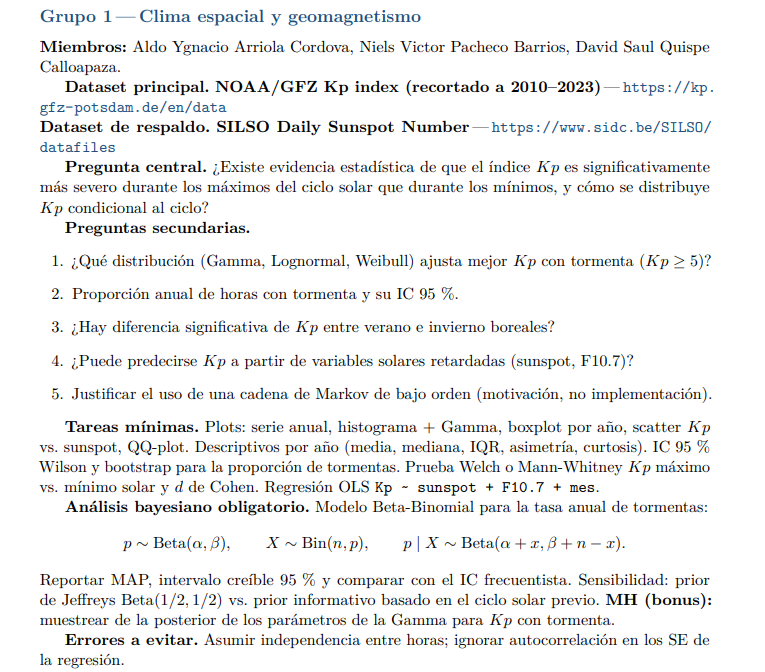

In [15]:
from datetime import datetime, timedelta
import time
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns

In [2]:
# Configuración estética global para el Notebook
plt.rcParams.update({
    "figure.facecolor": "white",    
    "axes.facecolor": "white",      
    "axes.edgecolor": "#333333",      
    "axes.linewidth": 0.8,
    "axes.grid": True,         
    "grid.color": "#e2e2e2",          
    "grid.linestyle": "--",      
    "grid.alpha": 0.7,
    "font.family": "sans-serif",     
    "font.size": 11,
    "axes.labelsize": 12,              
    "axes.titlesize": 14,              
    "xtick.labelsize": 10,             
    "ytick.labelsize": 10,            
    "figure.dpi": 100                  
})

## Loading the data

In [ ]:
# geomagnetic and solar indices
# days : number of days since 1932-01-01
# days_m : mean day of days
# BSR : Bartels Solar Rotation Number, it changes every 27 days
# dB : specific day in the 1 - 27 range of the Bartels Solar Rotation Number
# Kp_i : pertubation index for the 3-hour interval i (00, 03, 06, 09, 12, 15, 18, 21) cuasi log scale 0 - 9
# ap_i : planetary index for the 3-hour interval i (00, 03, 06, 09, 12, 15, 18, 21), in nT, linear scale 0 - 400
# Ap : daily mean planetary index, in nT, linear scale 0 - 400....
# SN : Sunspot number
# D : if D = 2, we are working with definitve data, valided data

df_geom = pd.read_csv("data/geomagnetic-solarindices.txt", sep=r"\s+",header=None)
df_geom.columns = [
                    "year", "month", "day", "days", "days_m", 
                    "BSR", "dB", "Kp_00", "Kp_03", "Kp_06", 
                    "Kp_09", "Kp_12", "Kp_15", "Kp_18", "Kp_21", 
                    "ap_00","ap_03","ap_06","ap_09","ap_12","ap_15", 
                    "ap_18","ap_21","Ap", "SN", "F10.7obs", "F10.7adj", "D"
                ]
df_geom["date"] = pd.to_datetime(df_geom[["year", "month", "day"]])
print("Kp and solar indices Dataset")
df_geom.head()

Kp and solar indices Dataset


,year,month,day,days,days_m,BSR,dB,Kp_00,Kp_03,Kp_06,...,ap_12,ap_15,ap_18,ap_21,Ap,SN,F10.7obs,F10.7adj,D,date
0,2010,1,1,28490,28490.5,2407,15,0.000,0.000,0.000,...,0,0,0,4,0,18,75.2,72.7,2,2010-01-01
1,2010,1,2,28491,28491.5,2407,16,0.000,0.000,0.333,...,0,2,2,2,1,21,78.0,75.4,2,2010-01-02
2,2010,1,3,28492,28492.5,2407,17,0.333,1.333,0.667,...,6,3,0,2,4,16,76.4,73.8,2,2010-01-03
3,2010,1,4,28493,28493.5,2407,18,0.333,0.000,1.333,...,2,0,2,0,2,15,73.0,70.6,2,2010-01-04
4,2010,1,5,28494,28494.5,2407,19,0.000,0.000,0.000,...,3,4,2,0,1,10,76.8,74.3,2,2010-01-05


In [6]:
# sunspot number dataset
df_sn = pd.read_csv("data/SN_d_tot_V2.0.txt", sep=r"\s+", header=None)
df_sn.columns = ["year", "month", "day", "date_year_fraction", "daily_total_sn", "daily_std_sn", "obs_number"]#, "indicator"]
# only years from 2010 to 2023
df_sn = df_sn[(2010<=df_sn["year"]) & (df_sn["year"]<=2023)  ]
df_sn["date"] = pd.to_datetime(df_sn[["year", "month", "day"]])
print("Sunspot Number Dataset")
df_sn.head()

Sunspot Number Dataset


,year,month,day,date_year_fraction,daily_total_sn,daily_std_sn,obs_number,date
70127,2010,1,1,2010.001,18,1.3,15,2010-01-01
70128,2010,1,2,2010.004,21,1.2,16,2010-01-02
70129,2010,1,3,2010.007,16,2.0,17,2010-01-03
70130,2010,1,4,2010.010,15,0.8,14,2010-01-04
70131,2010,1,5,2010.012,10,2.3,17,2010-01-05


In [13]:
kp_cols = ["Kp_00", "Kp_03", "Kp_06", "Kp_09", "Kp_12", "Kp_15", "Kp_18", "Kp_21"]
df_kp = pd.melt(df_geom, id_vars=["year", "month", "day"], value_vars=kp_cols, var_name="hour_str", value_name="Kp")
df_kp["hour"] = df_kp["hour_str"].str.replace("Kp_", "")
df_kp["datetime"] = pd.to_datetime(
    df_kp["year"].astype(str) + "-" + df_kp["month"].astype(str) + "-" + df_kp["day"].astype(str)
    + " " + df_kp["hour"]+ ":00:00" 
    )
df_kp = df_kp[["datetime", "Kp"]].sort_values("datetime").reset_index(drop=True)
df_kp.head()

,datetime,Kp
0,2010-01-01 00:00:00,0.0
1,2010-01-01 03:00:00,0.0
2,2010-01-01 06:00:00,0.0
3,2010-01-01 09:00:00,0.0
4,2010-01-01 12:00:00,0.0


In [8]:
df_kp

,datetime,Kp
0,2010-01-01 00:00:00,0.000
1,2010-01-01 03:00:00,0.000
2,2010-01-01 06:00:00,0.000
3,2010-01-01 09:00:00,0.000
4,2010-01-01 12:00:00,0.000
...,...,...
40899,2023-12-31 09:00:00,0.333
40900,2023-12-31 12:00:00,0.333
40901,2023-12-31 15:00:00,0.667
40902,2023-12-31 18:00:00,1.000


Se logra observar, visuzalmente, una correlacion entre Kp y SN.


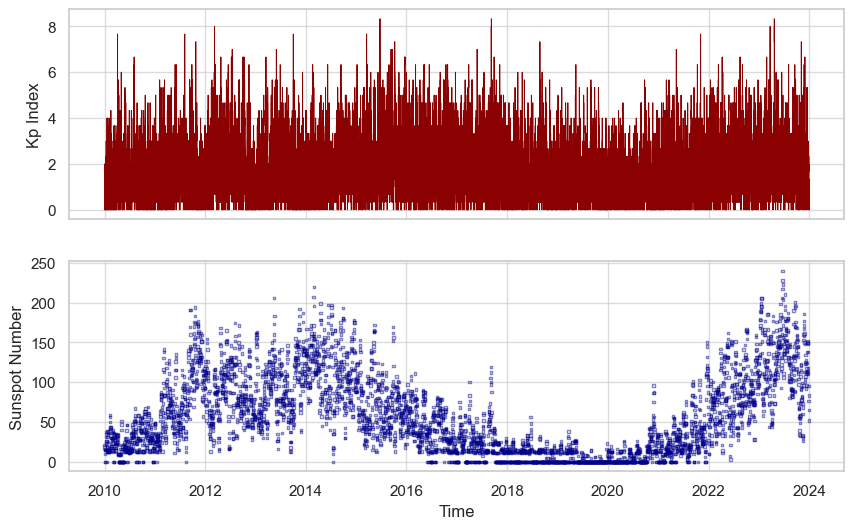

In [34]:
fig, axs = plt.subplots(nrows=2, figsize=(10,6), sharex=True)
ax = axs[0]
ax.step(df_kp["datetime"], df_kp["Kp"], color="darkred", lw=0.7)
#ax.scatter(df_kp["datetime"], df_kp["Kp"], marker="o", facecolor="none", edgecolor="darkred", s=3, alpha=0.5)
ax.set_ylabel("Kp Index")
ax = axs[1]
ax.scatter(df_geom["date"], df_geom["SN"], marker="s", facecolor="none", edgecolor="darkblue", s=3, alpha=0.5)
ax.set_ylabel("Sunspot Number")

plt.xlabel("Time")

print("Se logra observar, visuzalmente, una correlacion entre Kp y SN.")

Text(0, 0.5, 'Sunspot')

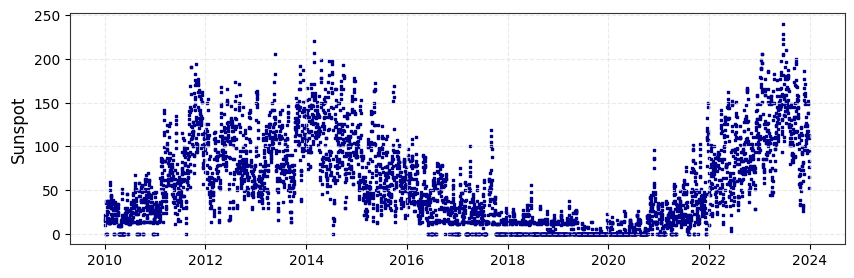

In [10]:
fig, ax = plt.subplots(nrows=1, figsize=(10,3), sharex=True)
ax.scatter(df_sn["date"], df_sn["daily_total_sn"], color="darkblue", marker="s", s=3)
ax.set_ylabel("Sunspot")

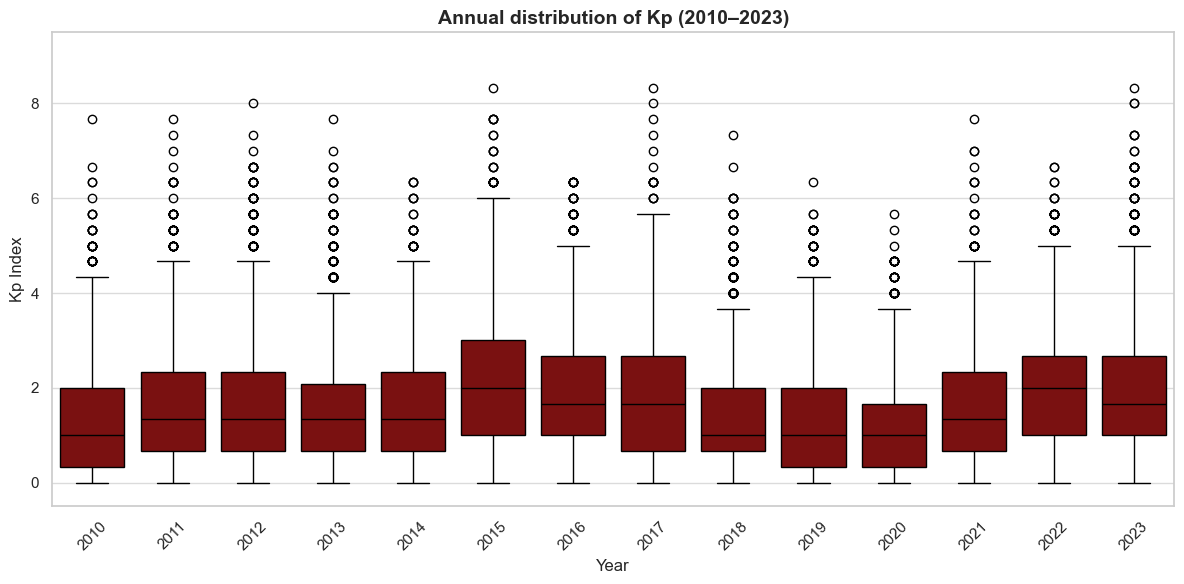

In [58]:
# Boxplot per year
df_kp['year'] = df_kp['datetime'].dt.year

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_kp, x="year", y="Kp", color = 'darkred', linecolor = 'black')

plt.title("Annual distribution of Kp (2010–2023)", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Kp Index", fontsize=12)
plt.ylim(-0.5, 9.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

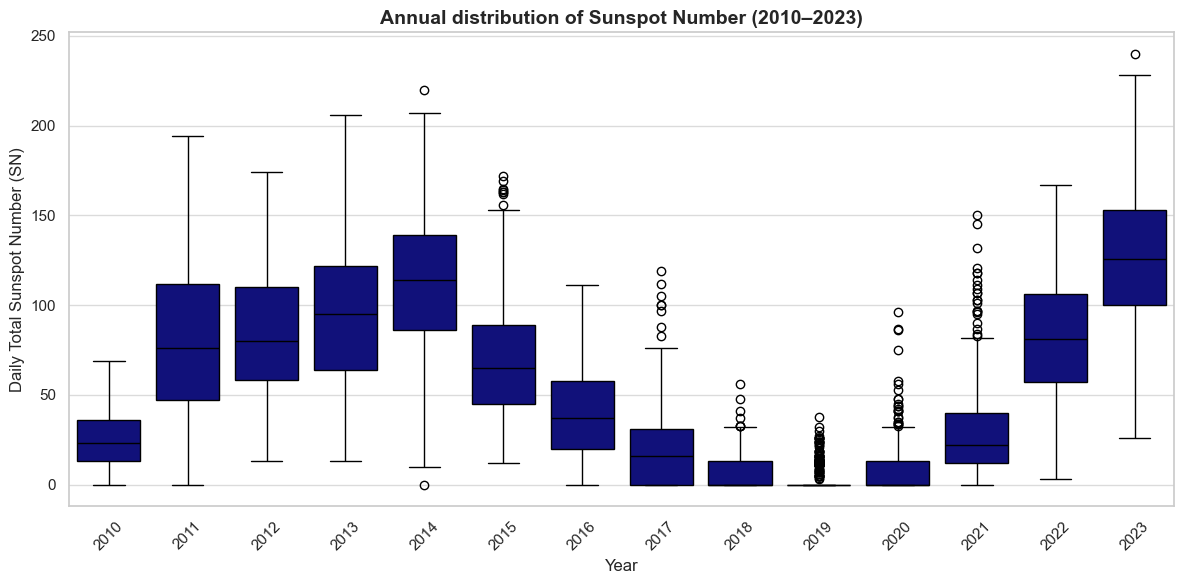

In [55]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_sn, x="year", y="daily_total_sn", color = 'darkblue', linecolor = 'black')

plt.title("Annual distribution of Sunspot Number (2010–2023)", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Daily Total Sunspot Number (SN)", fontsize=12)
#plt.ylim(-0.5, 9.5)
plt.xticks(rotation=45)
plt.tight_layout()

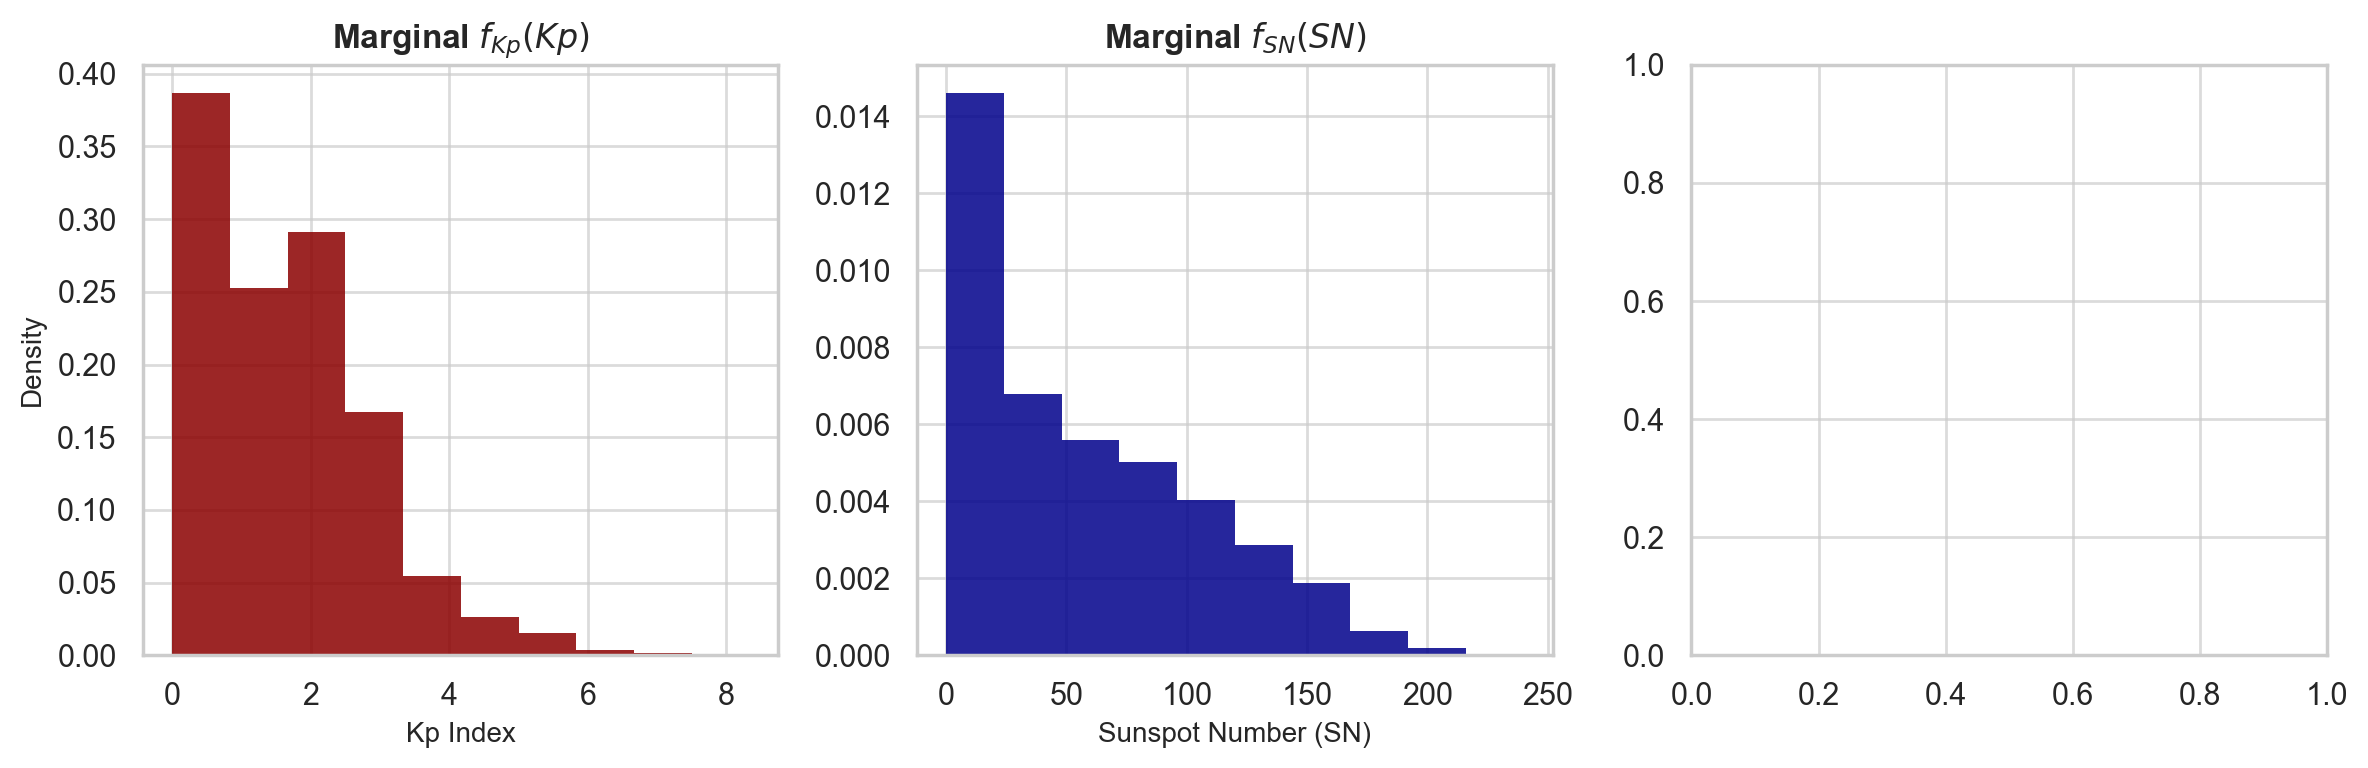

In [92]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi = 200)

axs[0].hist(df_kp["Kp"], bins = 10, color = 'darkred', density = True, edgecolor = 'none', alpha = 0.85)
axs[0].set_title(r"Marginal $f_{Kp}(Kp)$", fontsize=12, fontweight="bold")
axs[0].set_xlabel("Kp Index", fontsize=10)
axs[0].set_ylabel("Density", fontsize=10)

axs[1].hist(df_sn["daily_total_sn"], bins = 10, color = 'darkblue', density = True, edgecolor = 'none', alpha = 0.85)
axs[1].set_title(r"Marginal $f_{SN}(SN)$", fontsize=12, fontweight="bold")
axs[1].set_xlabel(r"Sunspot Number (SN)", fontsize=10)
#axs[1].set_ylabel("Density", fontsize=10)

#hb = axs[2].hexbin(df_kp["Kp"], df_sn["daily_total_sn"], gridsize=30, cmap='Blues', mincnt=1)

plt.tight_layout()